# Simulating an acquisition with a custom (non-database) dye

`01_simulating_an_acquisition.ipynb` simulated an acquisition with a database dye
(`"ATTO 647N"`) — looked up by name in `Spectral_Funcs`'s spectral database. This notebook
repeats that exact same workflow for a dye you define yourself: build an emission spectrum,
wrap it in `pattern_source.SimulatedDye`, and pass it to `simulate_acquisition` exactly where
a database dye name would otherwise go.

`SimulatedDye` is one of three non-database `colour_to_dye` values `simulate_acquisition`
accepts (`Scatterer`, for a non-fluorescent point scatterer like a gold-nanoparticle
fiducial, and `NileRedEnvironment`, for a physically-modelled Nile Red local-polarity
environment, are the other two — see their own docstrings) — the one for a hypothetical dye
defined by an arbitrary spectrum array, not a physical model.

In [1]:
from pathlib import Path
import tempfile
import json
import numpy as np
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
from pyS3M.clustering import ClusteringConfig
from pyS3M.simulation import pattern_source
import pyS3M.SpectralFunctions as SpectralFunctions
import pyS3M.IOFunctions as IOFunctions
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]
PATTERN_PATH = REPO_ROOT / "test_tiffs" / "example_SR_patterns" / "circles_onecolour.png"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)
plotter = PlottingBase.PublicationPlotter()

INFO:pyS3M.AnalysisPipeline:AnalysisPipeline initialised (camera=ximea, pixel_size=0.0690 µm)


INFO:pyS3M.AnalysisPipeline:Calibration loaded from /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/Camera_Calibrations/Ximea_Camera


## Build a custom emission spectrum

Say you want a hypothetical dye with a simple Gaussian emission, centred at 550 nm with a
20 nm FWHM — e.g. pasted in from a spectrometer trace in arbitrary intensity ("counts")
units, peak height 500. The *shape* is all that matters physically, but for the resulting
photon fractions to be correct, the array has to integrate to 1 over wavelength — i.e.
`np.trapz(spectrum, wavelength) == 1` — because the machinery behind `SimulatedDye`
(`Spectral_Funcs.get_pixel_fractions_rawspectra`) treats it as a probability density over
emission wavelength, not a raw intensity trace. Skip that and any expected-photon-count
calculation you do by hand from the un-normalised array is wrong by whatever factor its
integral is off by — `get_pixel_fractions_rawspectra` itself always renormalises before
using a spectrum, so it *always* returns a correct answer regardless of input scale, and
warns you when it had to, so a scaling mistake like this doesn't silently go unnoticed.

In [2]:
S_F = SpectralFunctions.Spectral_Funcs()
R_qe, G_qe, B_qe, wl = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_qe, G_qe, R_qe])  # (B, G, R) order

sigma_nm = S_F.fwhm_sigma_conversion(20.0, sigma_given=False)
raw_spectrum = 500.0 * np.exp(-0.5 * ((wl - 550.0) / sigma_nm) ** 2)  # NOT normalised
print(f"raw_spectrum integral = {np.trapz(raw_spectrum, wl):.1f} (should be 1)")

# get_pixel_fractions_rawspectra warns (see below) and corrects this for you --
# the returned fracs are the true per-channel photon fractions either way.
avg_wl, fracs = S_F.get_pixel_fractions_rawspectra(raw_spectrum, wl, pixel_QYs)
n_photons_total = 4000

# What happens if you instead compute expected photons per channel by hand from
# the un-normalised array, forgetting to divide by its own integral first:
naive_photons = n_photons_total * np.trapz(raw_spectrum[None, :] * pixel_QYs, wl, axis=1)
correct_photons = n_photons_total * fracs
print(f"naive (WRONG) per-channel photons:   {naive_photons.round(0)}, "
      f"sum={naive_photons.sum():.0f} (of {n_photons_total} total -- impossible)")
print(f"correct per-channel photons:         {correct_photons.round(0)}, "
      f"sum={correct_photons.sum():.0f} (of {n_photons_total} total)")

# The array simulate_acquisition will actually use -- normalised once, up front, so it's
# not relying on get_pixel_fractions_rawspectra's auto-correction (and its warning) below.
normalised_spectrum = raw_spectrum / np.trapz(raw_spectrum, wl)

raw_spectrum integral = 10644.7 (should be 1)
naive (WRONG) per-channel photons:   [  2530564.  26799779.   1500197.], sum=30830540 (of 4000 total -- impossible)
correct per-channel photons:         [  238.  2518.   141.], sum=2896 (of 4000 total)


/tmp/ipykernel_2304285/2051584310.py:11: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 10644.67019431]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  avg_wl, fracs = S_F.get_pixel_fractions_rawspectra(raw_spectrum, wl, pixel_QYs)


## Wire it into `simulate_acquisition` via `SimulatedDye`

`SimulatedDye(spectrum, wavelength_nm, label=...)` wraps the array above for use as a
`colour_to_dye` value in place of a database dye name — pass it a spectrum on *any*
wavelength grid (here, conveniently, the same one `getpixelefficiency()` returned above) and
it interpolates onto `simulate_acquisition`'s own internal grid before use, the same way a
database dye's stored spectrum already is. Everything else — `filter_names`, `photon_range`,
writing to disk, fitting — is identical to the database-dye workflow in
`01_simulating_an_acquisition.ipynb`.

In [3]:
dye = pattern_source.SimulatedDye(normalised_spectrum, wl, label="synthetic 550nm dye")

camera_pixel_size_nm = pipe.pixel_size * 1000.0
width, height = pattern_source.image_fov_camera_pixels(PATTERN_PATH, camera_pixel_size_nm)
print(f"Field of view: {width}x{height} camera px")

bayer_stack, ground_truth, width, height, avg_wl_nm = pattern_source.simulate_acquisition(
    image=PATTERN_PATH,
    colour_to_dye={(0, 0, 0): dye},
    camera=pipe.camera,
    pixel_size_um=pipe.pixel_size,
    gain_map=pipe.gain_map[:height, :width],
    offset_map=pipe.offset_map[:height, :width],
    variance_map=pipe.variance[:height, :width],
    rqe_map=pipe.rqe[:height, :width],
    n_frames=200,
    density_per_um2=0.1,
    modality="PAINT",
    filter_names=["semrock-ff01-550-49"],  # 550/49 nm bandpass -- see 01's filter markdown
    photon_range=(4000.0, 10000.0),
    background_photons=10.0,
    rng=np.random.default_rng(0),
)
print(f"{bayer_stack.shape[0]} frames simulated, {len(ground_truth)} candidates, "
      f"recommended Peak λ = {avg_wl_nm / 1000.0:.3f} µm")
ground_truth.head()

Field of view: 145x145 camera px


200 frames simulated, 38 candidates, recommended Peak λ = 0.550 µm


,dye,colour,xc_nm,yc_nm,n_frames_on
0,synthetic 550nm dye,#000000,6658.646235,8018.131244,10
1,synthetic 550nm dye,#000000,4250.474283,6175.207508,2
2,synthetic 550nm dye,#000000,1096.624795,4513.972365,0
3,synthetic 550nm dye,#000000,2517.259327,2099.554882,1
4,synthetic 550nm dye,#000000,8310.172565,2484.092617,8


## A raw simulated frame

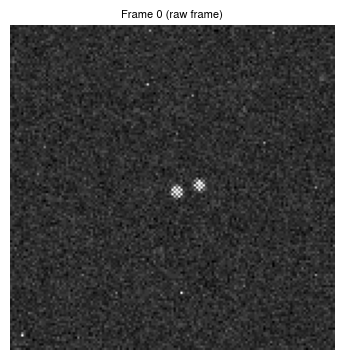

In [4]:
fig, ax = plotter.one_column_plot()
ax = plotter.image_plot(ax, bayer_stack[0], vmin=np.percentile(bayer_stack[0], 0.1),
                       vmax=np.percentile(bayer_stack[0], 99.9))
ax[0].set_title("Frame 0 (raw frame)")
plt.show()

## Write to disk and fit — the same pipeline every analysis notebook uses

Written to a temporary directory here so running this notebook doesn't leave files behind
in the repo. `FittingConfig.peak_wavelength` uses `avg_wl_nm` -- the same `SimulatedDye`
spectrum's own emission-weighted mean wavelength `simulate_acquisition` returned above --
exactly like the database-dye notebook.

In [5]:
out_dir = Path(tempfile.mkdtemp()) / "simulated_acquisition"
out_dir.mkdir(parents=True)
io = IOFunctions.IO_Functions()
io.write_tiff(bayer_stack, out_dir / "sim_MMStack_Default.ome.tif", bit="uint16", pixel_size=pipe.pixel_size)
with open(out_dir / "sim_MMStack_Default_metadata.txt", "w") as f:
    json.dump({"FrameKey-0-0-0": {"ROI": f"0-0-{width}-{height}"}}, f)

fc = FittingConfig(peak_wavelength=avg_wl_nm / 1000.0, pfa=1e-3)
pipe.fit(out_dir, mode="smlm", fitting_config=fc)
locs = pipe.load_localisations(out_dir)
cc = ClusteringConfig(min_cluster_size=2)  # PAINT-modality fixture -- see 01
sm_db, sf_db = pipe.filter_and_cluster(locs, clustering_config=cc)
print(f"{len(sm_db)} molecules recovered from {len(locs)} raw localisations "
      f"({len(ground_truth)} candidates injected)")

INFO:pyS3M.AnalysisPipeline:Starting smlm fit on /tmp/tmptu018lq3/simulated_acquisition


INFO:pyS3M.SR_Functions:Processing file 1/1: 200 frames in chunks of 1000


INFO:pyS3M.SR_Functions:  Processing chunk: frames 0-199


Detecting puncta:   0%|          | 0/200 [00:00<?, ?it/s]

INFO:pyS3M.SR_Functions:  Found 418 puncta across all chunks


INFO:pyS3M.AnalysisPipeline:smlm fit complete


INFO:pyS3M.AnalysisPipeline:Loaded 236 localisations from 1 file(s) in /tmp/tmptu018lq3/simulated_acquisition


INFO:pyS3M.AnalysisPipeline:Clustering with HDBSCAN (min_cluster_size=2)


INFO:pyS3M.clustering.hdbscan_clusterer:Using fast_hdbscan for HDBSCAN clustering


19 molecules recovered from 236 raw localisations (38 candidates injected)


## Recovered positions vs. injected ground truth

As in `01_simulating_an_acquisition.ipynb`, don't expect full recovery here — 200 frames
is a short PAINT acquisition, so many candidates only bind once (or not at all) in the
whole movie and are never distinguishable from noise.

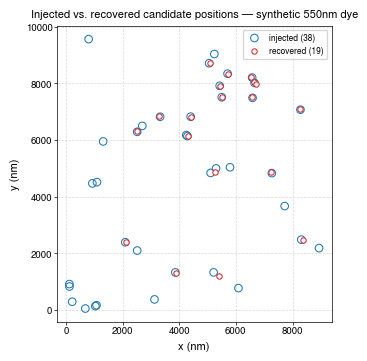

In [6]:
pixel_size_nm = pipe.pixel_size * 1000.0
fig, ax = plotter.create_figure()
plotter.scatter_plot(ax, ground_truth["xc_nm"], ground_truth["yc_nm"], xlabel="x (nm)", ylabel="y (nm)",
                      size=30, edgecolor="tab:blue", facecolor="none", label=f"injected ({len(ground_truth)})")
plotter.scatter_plot(ax, sm_db["xc"] * pixel_size_nm, sm_db["yc"] * pixel_size_nm, xlabel="x (nm)", ylabel="y (nm)",
                      size=15, color="tab:red", edgecolor="tab:red", label=f"recovered ({len(sm_db)})")
ax.set_aspect("equal")
ax.set_title("Injected vs. recovered candidate positions — synthetic 550nm dye")
ax.legend()
plt.show()

## Next: `03_exemplar_psf_and_bayer_grid.ipynb`